In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_path = Path("/Users/irinafendley/Projects/Loan_Default")

data_path = project_path / "data/processed/loan_clean.csv"

df = pd.read_csv(data_path)



In [32]:
target_dist = (
    df["Default"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
      .rename(index={False: "Repaid", True: "Defaulted"})
      .to_frame("Share of Borrowers (%)")
)

target_dist


,Share of Borrowers (%)
Default,
Repaid,88.39
Defaulted,11.61


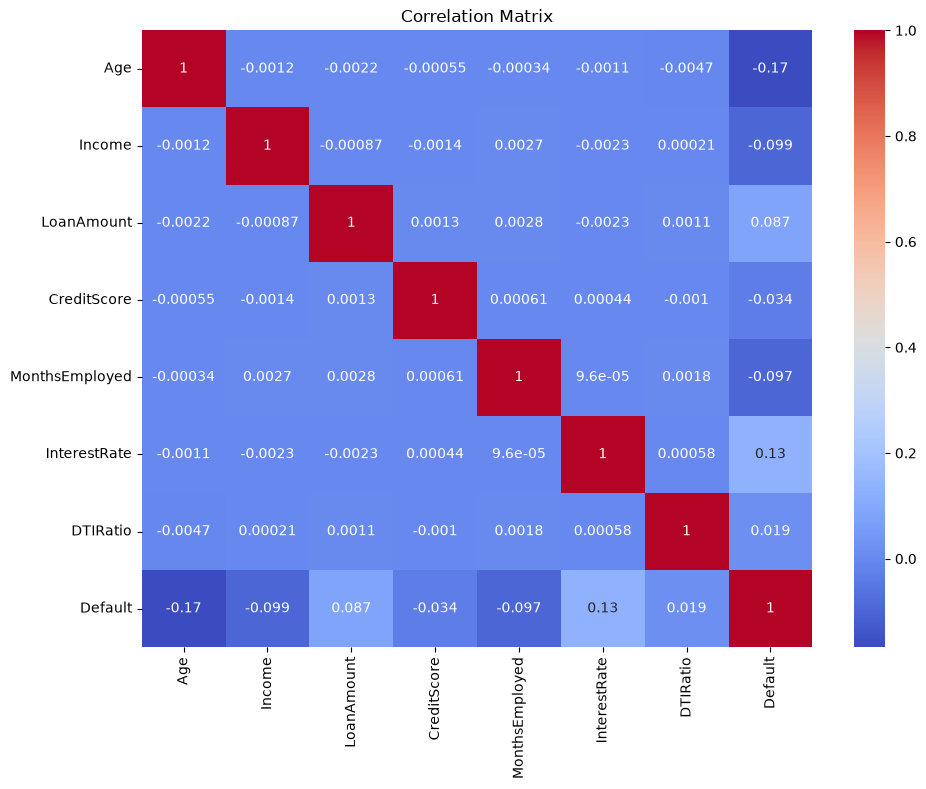

In [24]:

numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "InterestRate",
    "DTIRatio",
]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols + ["Default"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(project_path / "visuals/correlation_heatmap.png")

plt.show()


In [31]:
corr_default = (
    df.corr(numeric_only=True)["Default"]
      .sort_values()
      .to_frame("Correlation with Default")
)

corr_default

,Correlation with Default
Age,-0.167783
Income,-0.099119
MonthsEmployed,-0.097374
HasCoSigner,-0.039109
HasDependents,-0.034678
CreditScore,-0.034166
HasMortgage,-0.022856
LoanTerm,0.000545
DTIRatio,0.019236
NumCreditLines,0.028330


In [27]:
corr_default_abs = (
    df.corr(numeric_only=True)["Default"]
      .abs()
      .sort_values(ascending=False)
)

print("Absolute Correlation with Default")
print(corr_default_abs)

Absolute Correlation with Default
Default           1.000000
Age               0.167783
InterestRate      0.131273
Income            0.099119
MonthsEmployed    0.097374
LoanAmount        0.086659
HasCoSigner       0.039109
HasDependents     0.034678
CreditScore       0.034166
NumCreditLines    0.028330
HasMortgage       0.022856
DTIRatio          0.019236
LoanTerm          0.000545
Name: Default, dtype: float64


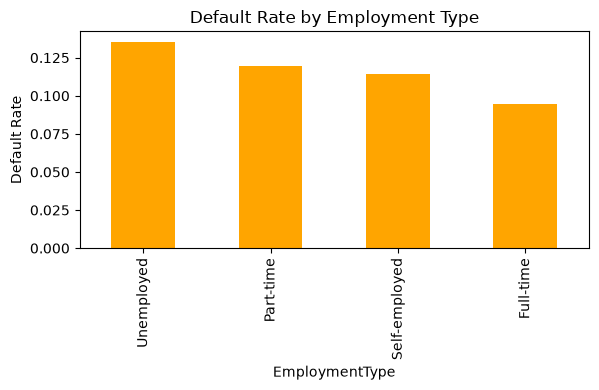

In [28]:
plt.figure(figsize=(6, 4))

ax = cat_risk.plot(kind="bar", color="orange")

plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate")

plt.tight_layout()
plt.savefig(project_path / "visuals/employment_risk.png")
plt.show()

In [9]:
print(df.groupby('EmploymentType')['Default'].mean().sort_values(ascending=False))


EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64


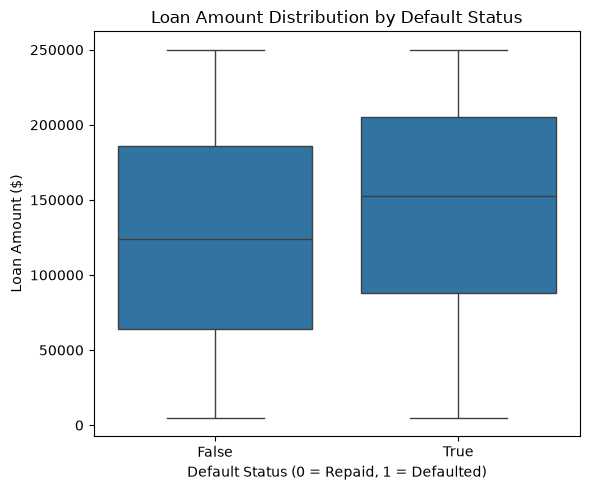

In [29]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="Default", y="LoanAmount", data=df)
plt.title("Loan Amount Distribution by Default Status")
plt.xlabel("Default Status (0 = Repaid, 1 = Defaulted)")
plt.ylabel("Loan Amount ($)")
plt.tight_layout()
plt.savefig(project_path / "visuals/loan_amount_boxplot.png")
plt.show()

In [39]:
print("Loan Amount Summary by Default Status")
print("-------------------------------------")

loan_summary = df.groupby("Default")["LoanAmount"].agg(
    ["count", "mean", "median", "min", "max"]
)
loan_summary.index = ["Repaid", "Defaulted"]
loan_summary

Loan Amount Summary by Default Status
-------------------------------------


,count,mean,median,min,max
Repaid,225694,125353.656017,124236.0,5001,249999
Defaulted,29653,144515.311469,152672.0,5000,249993


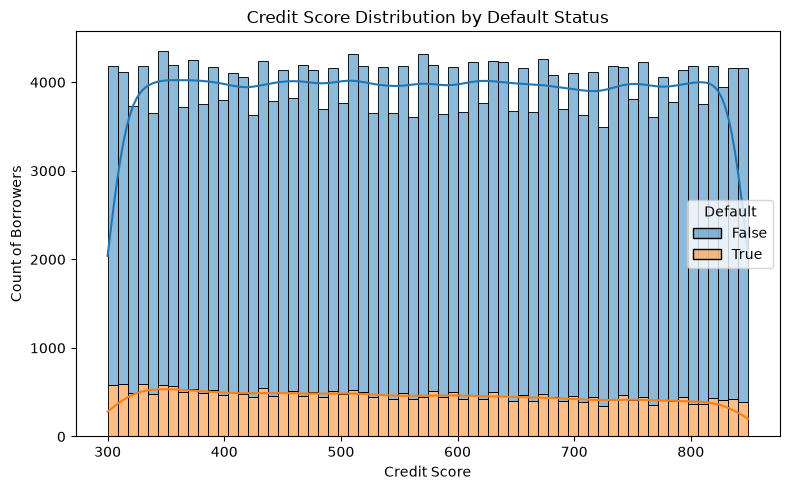

In [30]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="CreditScore", hue="Default", kde=True, multiple="stack")
plt.title("Credit Score Distribution by Default Status")
plt.xlabel("Credit Score")
plt.ylabel("Count of Borrowers")
plt.tight_layout()
plt.savefig(project_path / "visuals/credit_score_distribution.png")
plt.show()

In [40]:
print("Credit Score Summary by Default Status")
print("--------------------------------------")

credit_summary = df.groupby("Default")["CreditScore"].agg(
    ["mean", "median", "min", "max"]
)
credit_summary.index = ["Repaid", "Defaulted"]
credit_summary

Credit Score Summary by Default Status
--------------------------------------


,mean,median,min,max
Repaid,576.232270,577.0,300,849
Defaulted,559.286143,553.0,300,849


<Figure size 800x500 with 0 Axes>

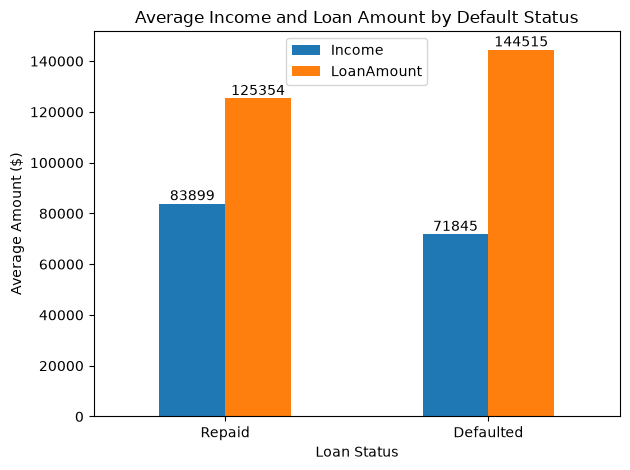

In [42]:
plt.figure(figsize=(8, 5))

ax = (
    df.groupby("Default")[["Income", "LoanAmount"]]
      .mean()
      .rename(index={False: "Repaid", True: "Defaulted"})
      .plot(kind="bar")
)

plt.title("Average Income and Loan Amount by Default Status")
plt.xlabel("Loan Status")
plt.ylabel("Average Amount ($)")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()

plt.savefig(project_path / "visuals/income_loan_by_default.png")

plt.show()

In [41]:
print("Average Income and Loan Amount by Default Status")
print("------------------------------------------------")

income_loan_summary = df.groupby("Default")[["Income", "LoanAmount"]].mean()
income_loan_summary.index = ["Repaid", "Defaulted"]
income_loan_summary

Average Income and Loan Amount by Default Status
------------------------------------------------


,Income,LoanAmount
Repaid,83899.165995,125353.656017
Defaulted,71844.722659,144515.311469


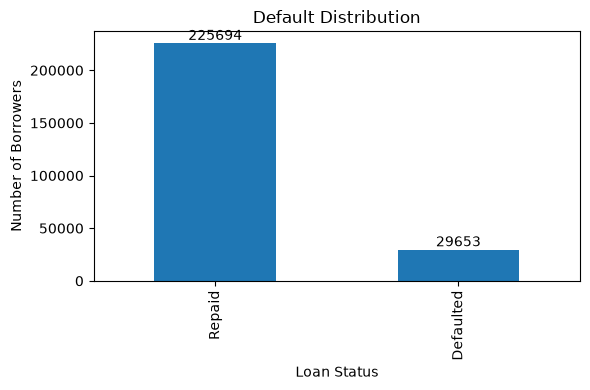

In [3]:
plt.figure(figsize=(6, 4))

ax = df["Default"].value_counts().rename({False: "Repaid", True: "Defaulted"}).plot(kind="bar")

plt.title("Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Borrowers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(project_path / "visuals/default_distribution.png")
plt.show()

In [4]:
print("Default Distribution (counts and %)")

default_dist = df["Default"].value_counts()
default_pct = df["Default"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": default_dist,
    "percent": default_pct.round(2)
})

summary.index = ["Repaid", "Defaulted"]
summary

Default Distribution (counts and %)


,count,percent
Repaid,225694,88.39
Defaulted,29653,11.61


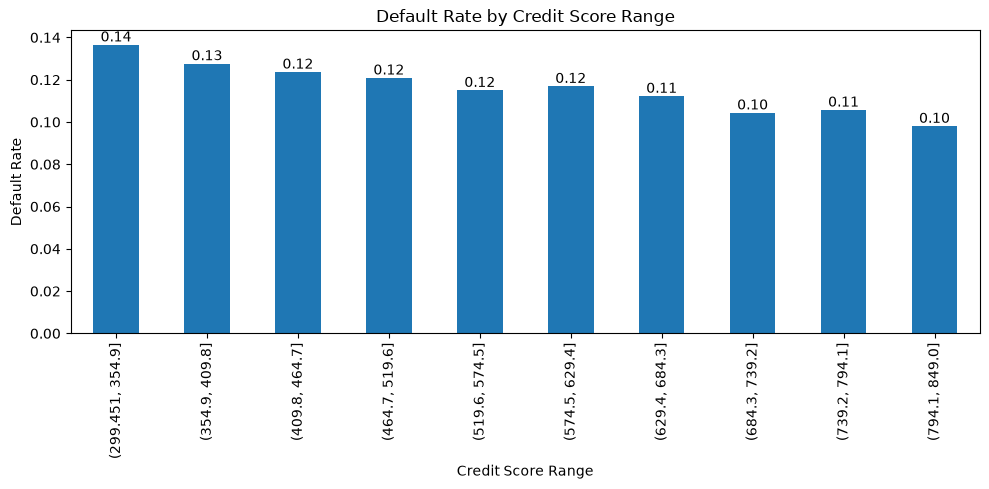

In [7]:
credit_bins = pd.cut(df["CreditScore"], bins=10)

default_rate_score = df.groupby(credit_bins)["Default"].mean()

plt.figure(figsize=(10, 5))

ax = default_rate_score.plot(kind="bar")

plt.title("Default Rate by Credit Score Range")
plt.xlabel("Credit Score Range")
plt.ylabel("Default Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig(project_path / "visuals/default_rate_credit_score.png")
plt.show()

In [8]:
print("Default Rate by Credit Score Range")

default_rate_score

Default Rate by Credit Score Range


CreditScore
(299.451, 354.9]    0.136527
(354.9, 409.8]      0.127636
(409.8, 464.7]      0.123685
(464.7, 519.6]      0.120882
(519.6, 574.5]      0.115022
(574.5, 629.4]      0.116924
(629.4, 684.3]      0.112256
(684.3, 739.2]      0.104364
(739.2, 794.1]      0.105717
(794.1, 849.0]      0.098034
Name: Default, dtype: float64

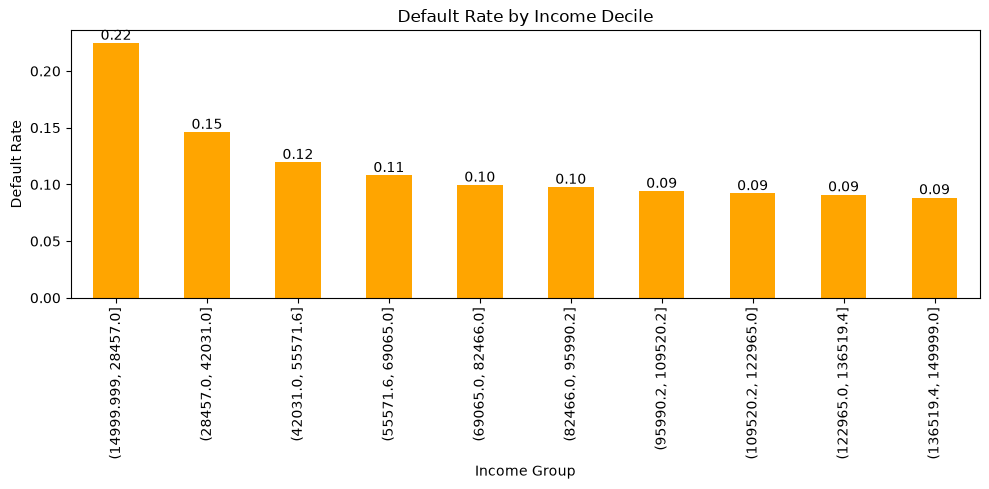

In [20]:
income_bins = pd.qcut(df["Income"], q=10)

default_rate_income = (
    df.groupby(income_bins)["Default"]
      .mean()
      .rename("Default Rate")
)

default_rate_income

plt.figure(figsize=(10, 5))

ax = default_rate_income.plot(kind="bar", color="orange")

plt.title("Default Rate by Income Decile")
plt.xlabel("Income Group")
plt.ylabel("Default Rate")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig(project_path / "visuals/default_rate_income.png")
plt.show()

In [16]:
print("Default Rate by Income Deciles")

default_rate_income

Default Rate by Income Deciles


Income
(14999.999, 28457.0]    0.224654
(28457.0, 42031.0]      0.146113
(42031.0, 55571.6]      0.119575
(55571.6, 69065.0]      0.108044
(69065.0, 82466.0]      0.099554
(82466.0, 95990.2]      0.097713
(95990.2, 109520.2]     0.094106
(109520.2, 122965.0]    0.092031
(122965.0, 136519.4]    0.091016
(136519.4, 149999.0]    0.088467
Name: Default Rate, dtype: float64

In [21]:
risk_rank = (
    df.corr(numeric_only=True)["Default"]
      .abs()
      .sort_values(ascending=False)
      .drop("Default")
      .to_frame("Absolute Correlation")
)

risk_rank

,Absolute Correlation
Age,0.167783
InterestRate,0.131273
Income,0.099119
MonthsEmployed,0.097374
LoanAmount,0.086659
HasCoSigner,0.039109
HasDependents,0.034678
CreditScore,0.034166
NumCreditLines,0.028330
HasMortgage,0.022856


In [22]:
comparison = df.groupby("Default")[["Income", "LoanAmount", "CreditScore"]].mean().T

comparison.columns = ["Repaid", "Defaulted"]

comparison["Difference"] = comparison["Defaulted"] - comparison["Repaid"]

comparison

,Repaid,Defaulted,Difference
Income,83899.165995,71844.722659,-12054.443336
LoanAmount,125353.656017,144515.311469,19161.655453
CreditScore,576.232270,559.286143,-16.946127


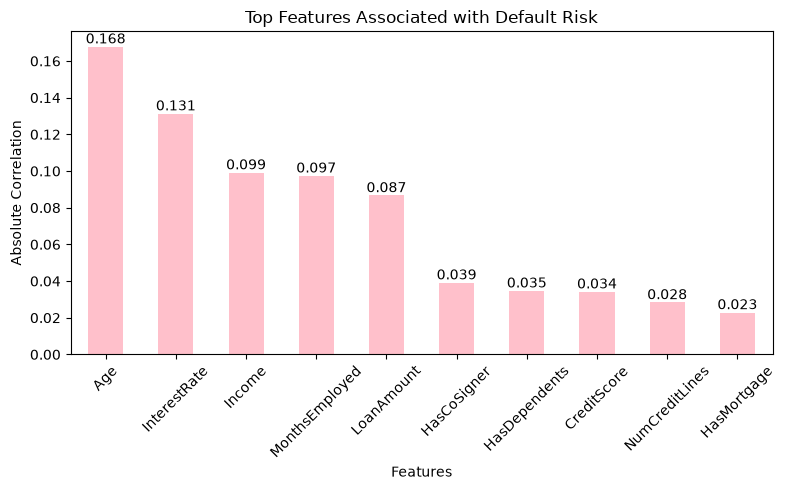

In [33]:
top_risk = (
    df.corr(numeric_only=True)["Default"]
      .abs()
      .sort_values(ascending=False)
      .drop("Default")
      .head(10)
)

plt.figure(figsize=(8, 5))

ax = top_risk.plot(kind="bar", color="pink")

plt.title("Top Features Associated with Default Risk")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(project_path / "visuals/top_risk_factors.png")
plt.show()

In [34]:
print("Top Risk Factors (Absolute Correlation with Default)")
print("---------------------------------------------------")

top_risk

Top Risk Factors (Absolute Correlation with Default)
---------------------------------------------------


Age               0.167783
InterestRate      0.131273
Income            0.099119
MonthsEmployed    0.097374
LoanAmount        0.086659
HasCoSigner       0.039109
HasDependents     0.034678
CreditScore       0.034166
NumCreditLines    0.028330
HasMortgage       0.022856
Name: Default, dtype: float64